In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('breast_cancer_dataset.xlsx')

In [5]:
!pip install watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.8 MB/s eta 0:00:00


In [6]:
import re
import unicodedata
import itertools

# Library for file manipulation
import pandas as pd
import numpy as np
import pandas

# Data visualisation
import seaborn as sns
import matplotlib.pylab as pl
import matplotlib as m
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib import pyplot as plt

# Configuration for graph width and layout
sns.set_theme(style='whitegrid')
palette='viridis'

# Warnings remove alerts
import warnings
warnings.filterwarnings("ignore")

# Python version
from platform import python_version
print('Python version in this Jupyter Notebook:', python_version())

# Load library versions
import watermark

# Library versions
%reload_ext watermark
%watermark -a "Library versions" --iversions

Python version in this Jupyter Notebook: 3.11.13
Author: Library versions

numpy     : 2.0.2
watermark : 2.5.0
matplotlib: 3.10.0
platform  : 1.0.8
seaborn   : 0.13.2
pandas    : 2.2.2
sklearn   : 1.6.1
re        : 2.2.1
plotly    : 5.24.1



In [7]:
pd.set_option('display.max_columns', None)
train_df = pd.read_excel("breast_cancer_dataset.xlsx")
train_df

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,1,2019,40,1,2,0,Right,0,Upper inner,0,Benign
1,2,2019,39,1,2,0,Left,0,Upper outer,0,Benign
2,3,2019,45,0,4,0,Left,0,Lower outer,0,Benign
3,4,2019,26,1,3,0,Left,0,Lower inner,1,Benign
4,5,2019,21,1,1,0,Right,0,Upper outer,1,Benign
...,...,...,...,...,...,...,...,...,...,...,...
208,209,2020,49,1,6,3,Right,1,Lower inner,1,Malignant
209,210,2020,28,1,3,0,Left,0,Upper inner,0,Benign
210,211,2020,22,1,1,0,Left,0,Upper outer,1,Benign
211,212,2020,19,1,1,0,Left,0,Lower inner,1,Benign


In [8]:
train_df.head()

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,1,2019,40,1,2,0,Right,0,Upper inner,0,Benign
1,2,2019,39,1,2,0,Left,0,Upper outer,0,Benign
2,3,2019,45,0,4,0,Left,0,Lower outer,0,Benign
3,4,2019,26,1,3,0,Left,0,Lower inner,1,Benign
4,5,2019,21,1,1,0,Right,0,Upper outer,1,Benign


In [9]:
train_df.tail()

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
208,209,2020,49,1,6,3,Right,1,Lower inner,1,Malignant
209,210,2020,28,1,3,0,Left,0,Upper inner,0,Benign
210,211,2020,22,1,1,0,Left,0,Upper outer,1,Benign
211,212,2020,19,1,1,0,Left,0,Lower inner,1,Benign
212,213,2020,50,0,4,0,Right,0,Lower outer,1,Benign


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   S/N               213 non-null    int64 
 1   Year              213 non-null    object
 2   Age               213 non-null    int64 
 3   Menopause         213 non-null    int64 
 4   Tumor Size (cm)   213 non-null    object
 5   Inv-Nodes         213 non-null    object
 6   Breast            213 non-null    object
 7   Metastasis        213 non-null    object
 8   Breast Quadrant   213 non-null    object
 9   History           213 non-null    object
 10  Diagnosis Result  213 non-null    object
dtypes: int64(3), object(8)
memory usage: 18.4+ KB


In [11]:
train_df.dtypes

,0
S/N,int64
Year,object
Age,int64
Menopause,int64
Tumor Size (cm),object
Inv-Nodes,object
Breast,object
Metastasis,object
Breast Quadrant,object
History,object


In [12]:
train_df.shape

(213, 11)

In [13]:
train_df = train_df.drop(columns=['S/N'])
train_df

,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,2019,40,1,2,0,Right,0,Upper inner,0,Benign
1,2019,39,1,2,0,Left,0,Upper outer,0,Benign
2,2019,45,0,4,0,Left,0,Lower outer,0,Benign
3,2019,26,1,3,0,Left,0,Lower inner,1,Benign
4,2019,21,1,1,0,Right,0,Upper outer,1,Benign
...,...,...,...,...,...,...,...,...,...,...
208,2020,49,1,6,3,Right,1,Lower inner,1,Malignant
209,2020,28,1,3,0,Left,0,Upper inner,0,Benign
210,2020,22,1,1,0,Left,0,Upper outer,1,Benign
211,2020,19,1,1,0,Left,0,Lower inner,1,Benign


In [14]:
train_df['Diagnosis Result'] = train_df['Diagnosis Result'].map({'Benign': 1, 'Malignant': 0})
train_df

,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,2019,40,1,2,0,Right,0,Upper inner,0,1
1,2019,39,1,2,0,Left,0,Upper outer,0,1
2,2019,45,0,4,0,Left,0,Lower outer,0,1
3,2019,26,1,3,0,Left,0,Lower inner,1,1
4,2019,21,1,1,0,Right,0,Upper outer,1,1
...,...,...,...,...,...,...,...,...,...,...
208,2020,49,1,6,3,Right,1,Lower inner,1,0
209,2020,28,1,3,0,Left,0,Upper inner,0,1
210,2020,22,1,1,0,Left,0,Upper outer,1,1
211,2020,19,1,1,0,Left,0,Lower inner,1,1


In [15]:
train_df.dtypes

,0
Year,object
Age,int64
Menopause,int64
Tumor Size (cm),object
Inv-Nodes,object
Breast,object
Metastasis,object
Breast Quadrant,object
History,object
Diagnosis Result,int64


In [16]:
df = train_df.copy()

EDA

In [17]:
print("\nDescriptive statistics of the training set")
train_df.describe().T


Descriptive statistics of the training set


,count,mean,std,min,25%,50%,75%,max
Age,213.0,39.784038,14.096712,13.0,30.0,40.0,49.0,77.0
Menopause,213.0,0.666667,0.472515,0.0,0.0,1.0,1.0,1.0
Diagnosis Result,213.0,0.563380,0.497135,0.0,0.0,1.0,1.0,1.0


In [18]:
categorical_features = train_df.select_dtypes(include=['object']).columns
numerical_features = train_df.select_dtypes(include=[np.number]).columns

print("\nCategorical Variables:", categorical_features)
print("Numeric Variables:", numerical_features)


Categorical Variables: Index(['Year', 'Tumor Size (cm)', 'Inv-Nodes', 'Breast', 'Metastasis',
       'Breast Quadrant', 'History'],
      dtype='object')
Numeric Variables: Index(['Age', 'Menopause', 'Diagnosis Result'], dtype='object')


In [19]:
for col in categorical_features:
    print(f"\nDistribution of categorical variable {col}:")
    print(train_df[col].value_counts())


Distribution of categorical variable Year:
Year
2020    111
2019    101
#         1
Name: count, dtype: int64

Distribution of categorical variable Tumor Size (cm):
Tumor Size (cm)
3     34
2     32
4     32
1     29
5     27
6     17
7     14
8     11
10     7
9      7
#      1
14     1
12     1
Name: count, dtype: int64

Distribution of categorical variable Inv-Nodes:
Inv-Nodes
0    139
1     72
#      1
3      1
Name: count, dtype: int64

Distribution of categorical variable Breast:
Breast
Left     107
Right    100
#          6
Name: count, dtype: int64

Distribution of categorical variable Metastasis:
Metastasis
0    139
1     73
#      1
Name: count, dtype: int64

Distribution of categorical variable Breast Quadrant:
Breast Quadrant
Upper outer     67
Lower outer     54
Upper inner     45
Lower inner     44
#                2
Upper outer      1
Name: count, dtype: int64

Distribution of categorical variable History:
History
0    124
1     87
#      2
Name: count, dtype: int64



Distribution of target variable 'Target':
Diagnosis Result
1    120
0     93
Name: count, dtype: int64


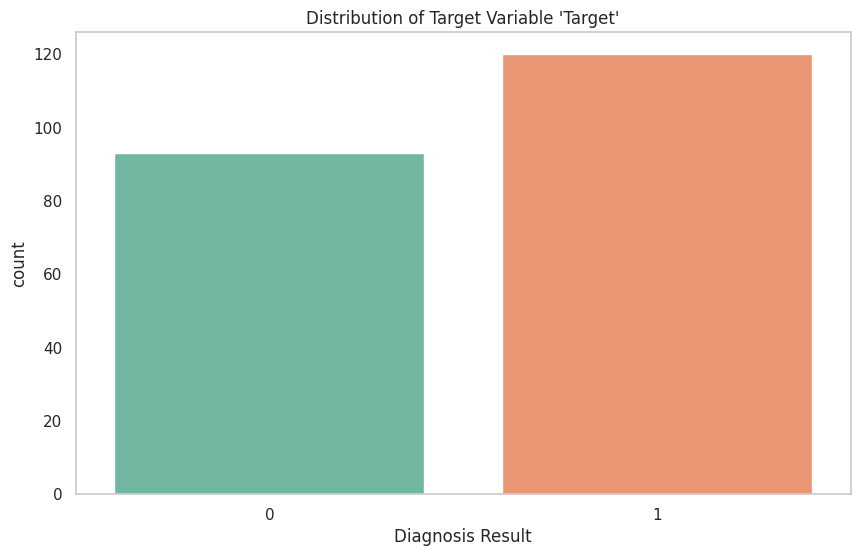

In [20]:
print("\nDistribution of target variable 'Target':")
print(train_df['Diagnosis Result'].value_counts())

# plot
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='Diagnosis Result', palette='Set2')
plt.title("Distribution of Target Variable 'Target'")
plt.grid(False)
plt.show()

Checking column 'Year' for '#' characters.
Attempted to convert column 'Year' to numeric. New dtype: float64
Checking column 'Tumor Size (cm)' for '#' characters.
Attempted to convert column 'Tumor Size (cm)' to numeric. New dtype: float64
Checking column 'Inv-Nodes' for '#' characters.
Attempted to convert column 'Inv-Nodes' to numeric. New dtype: float64
Checking column 'Breast' for '#' characters.
Attempted to convert column 'Breast' to numeric. New dtype: float64
Checking column 'Metastasis' for '#' characters.
Attempted to convert column 'Metastasis' to numeric. New dtype: float64
Checking column 'Breast Quadrant' for '#' characters.
Attempted to convert column 'Breast Quadrant' to numeric. New dtype: float64
Checking column 'History' for '#' characters.
Attempted to convert column 'History' to numeric. New dtype: float64

Data types of columns used for correlation:
Year                float64
Age                   int64
Menopause             int64
Tumor Size (cm)     float64
Inv-

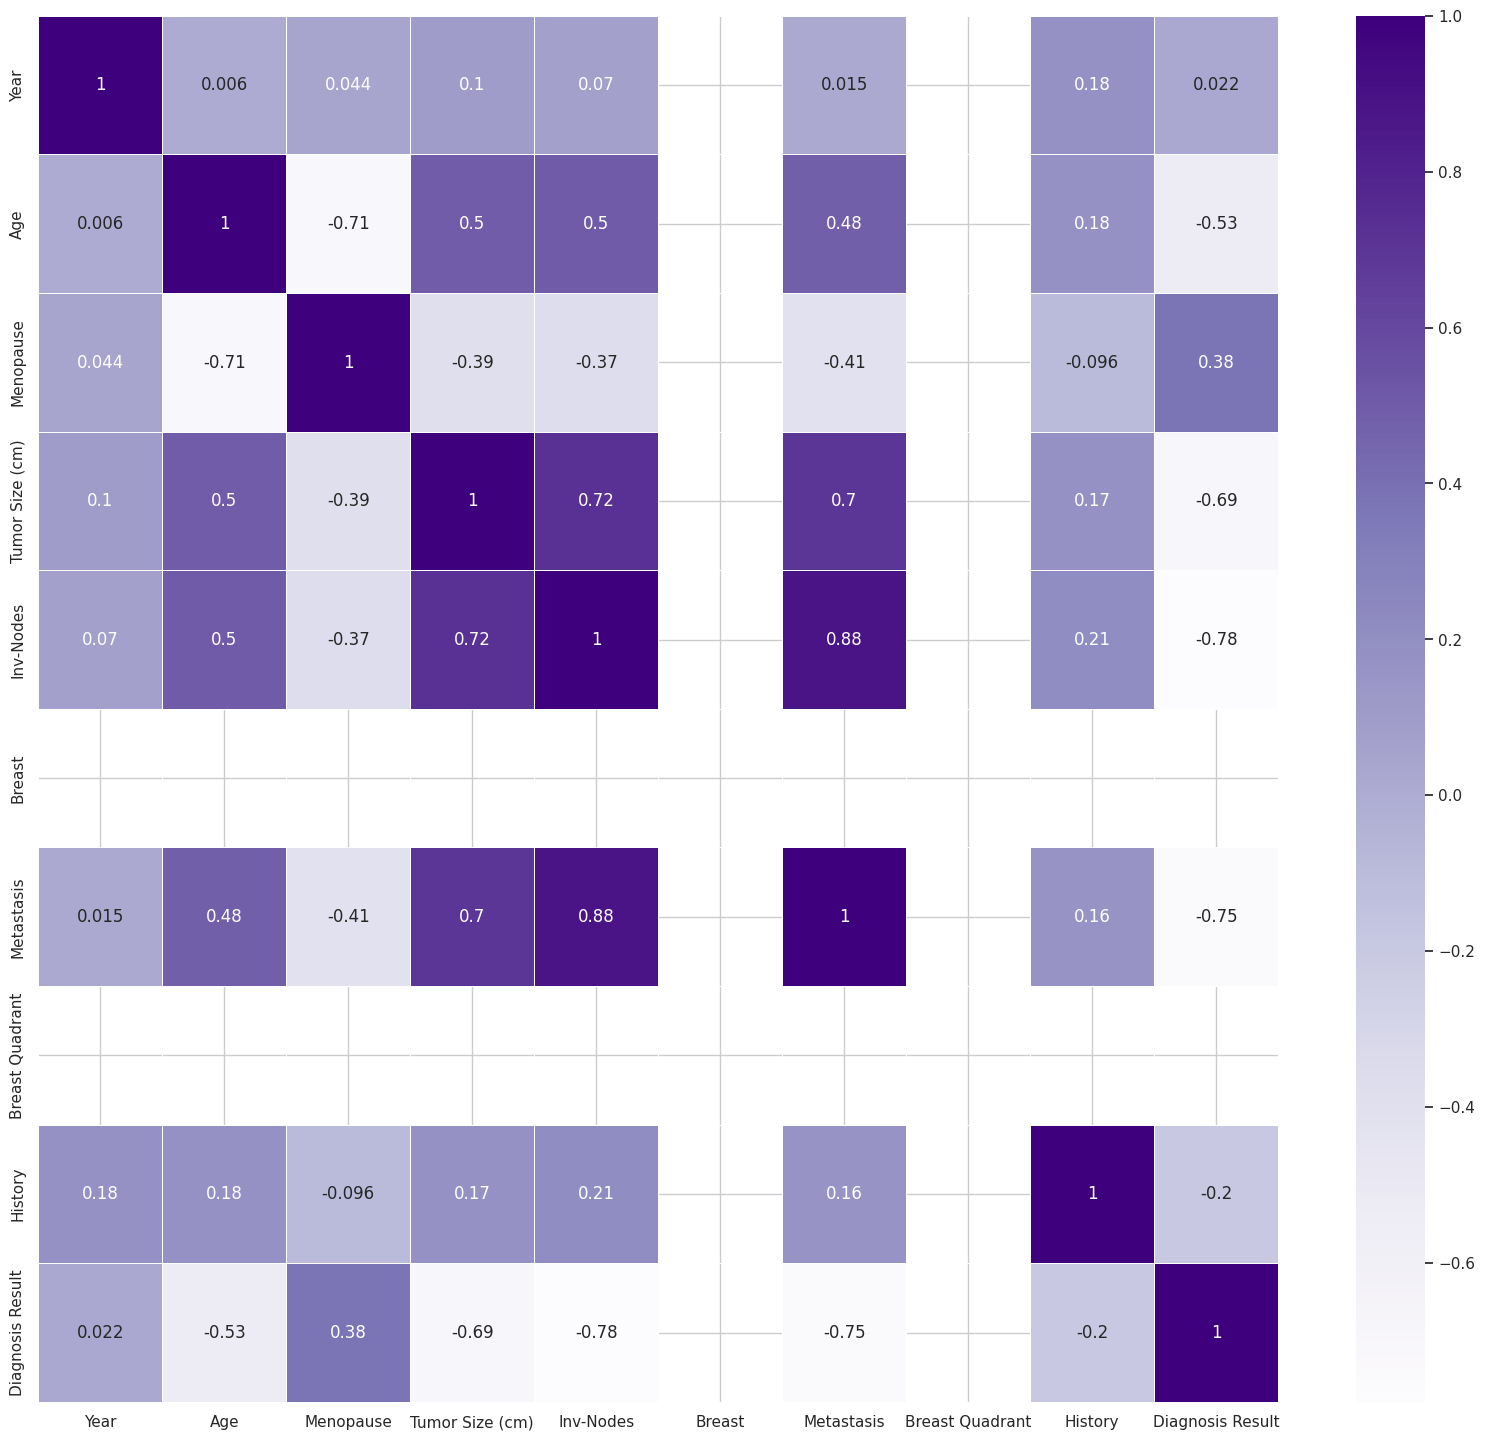

In [21]:
# Ensure the diagnosis column is numeric before calculating correlation for heatmap
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if the diagnosis column is already numeric to avoid unnecessary re-encoding
# The 'Diagnosis Result' column has already been mapped to numerical values (0 and 1)
# in a previous step, so re-encoding is not necessary.
# if df['diagnosis'].dtype == 'object':
#     labelencoder_Y = LabelEncoder()
#     df['diagnosis'] = labelencoder_Y.fit_transform(df['diagnosis'])

# --- Clean and convert columns to numeric before calculating correlation ---
# Iterate through all columns to find and clean any '#' characters
for col in df.columns:
    # Check if the column is of object/string type
    if pd.api.types.is_object_dtype(df[col]):
        print(f"Checking column '{col}' for '#' characters.")
        # Replace '#' with None (which becomes NaN after conversion to numeric)
        # Use regex=False as '#' is not a special regex character here
        df[col] = df[col].astype(str).str.replace('#', '', regex=False)

    # Attempt to convert all columns that should be numeric to numeric type
    # errors='coerce' will turn any values that cannot be converted (like empty strings or remaining non-numeric) into NaN
    # We do this for all columns as a safeguard, letting pandas handle which ones are truly convertible
    original_dtype = df[col].dtype
    df[col] = pd.to_numeric(df[col], errors='coerce')
    if df[col].dtype != original_dtype:
        print(f"Attempted to convert column '{col}' to numeric. New dtype: {df[col].dtype}")


# Drop rows with NaN values for the correlation calculation, as .corr() handles NaNs by default
# but ensuring no non-numeric values are left is the priority here.
# Note: Depending on how NaNs should be handled downstream, you might want to impute instead of drop.
# For the heatmap, dropping rows with NaNs in *any* relevant column will work.
# We'll focus on ensuring *all* data going into corr() is numeric or NaN.


# Select only numeric columns for correlation calculation
df_numeric = df.select_dtypes(include=[np.number])

# Handle potential remaining NaNs in numeric columns if needed for your analysis,
# though df.corr() handles them by default by computing pairwise correlation.
# If you want to drop rows with NaNs *before* corr:
# df_numeric = df_numeric.dropna()
# print(f"Shape after dropping rows with NaNs for correlation: {df_numeric.shape}")


# Verify data types before correlation calculation
print("\nData types of columns used for correlation:")
print(df_numeric.dtypes)

# --- Plotting Step ---
# Now calculate and plot the heatmap using the cleaned numeric DataFrame
plt.figure(figsize=(20,18))
# Use the DataFrame containing only numeric columns
sns.heatmap(df_numeric.corr(), annot=True,linewidths=.5, cmap="Purples")
plt.show()


Dropped 1 rows with NaN in 'Tumor Size (cm)'. New shape: (212, 10)
Data type of 'Tumor Size (cm)' after cleaning: float64

Features selected for distribution plotting: ['Age', 'Menopause', 'Tumor Size (cm)', 'Inv-Nodes', 'Breast', 'Metastasis', 'Breast Quadrant', 'History']


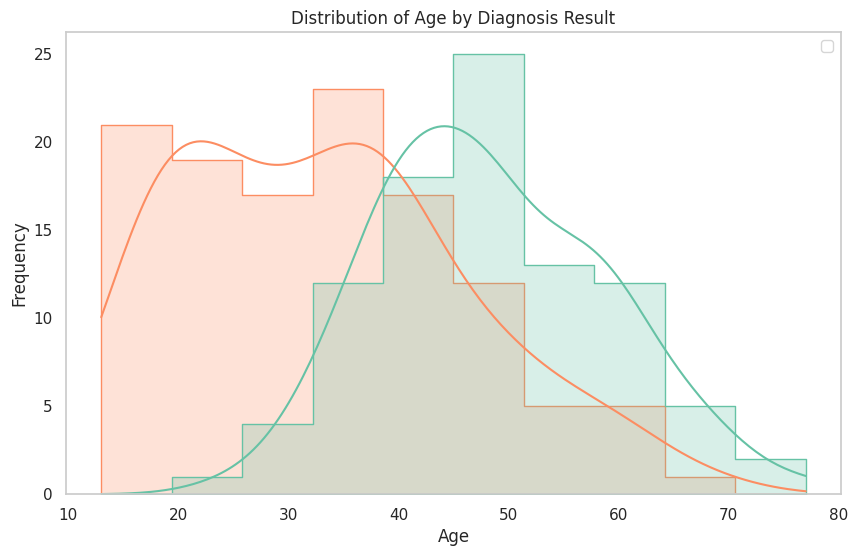

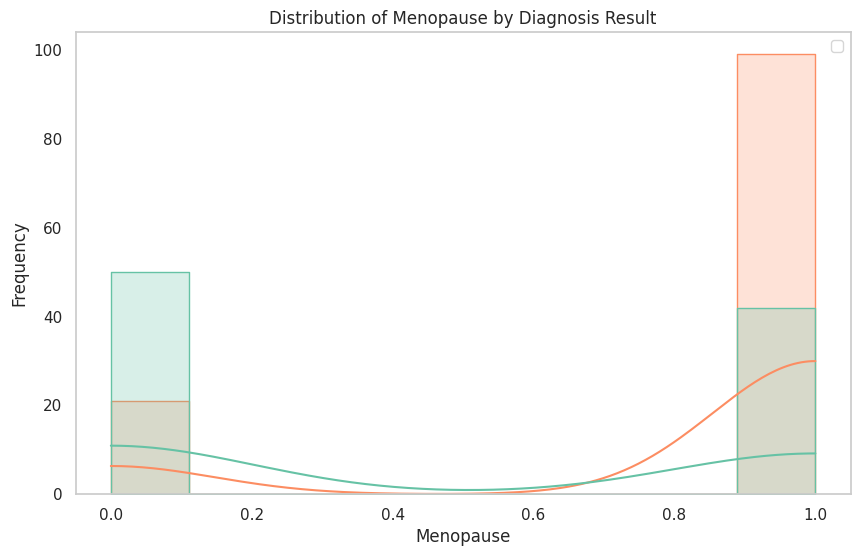

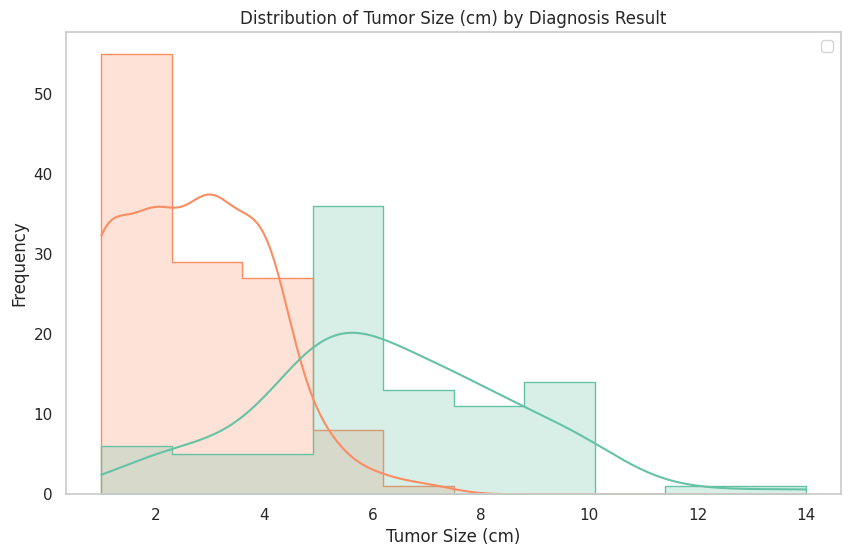

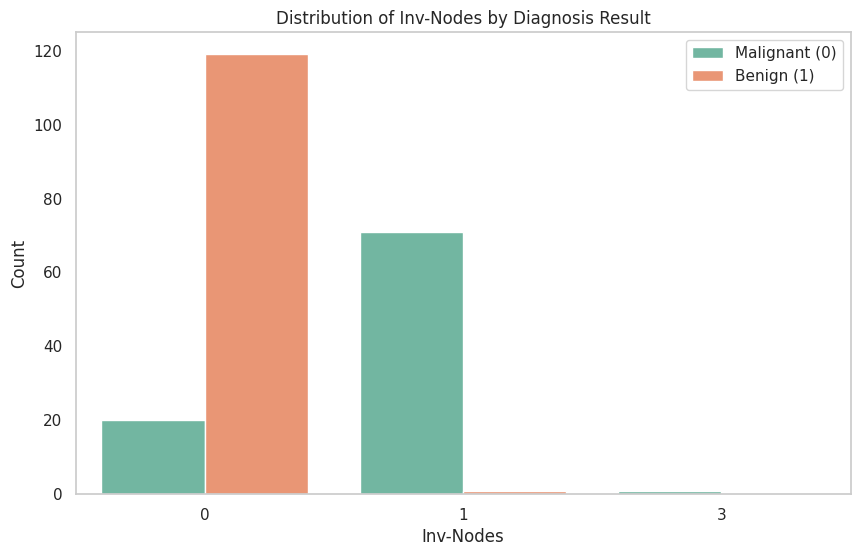

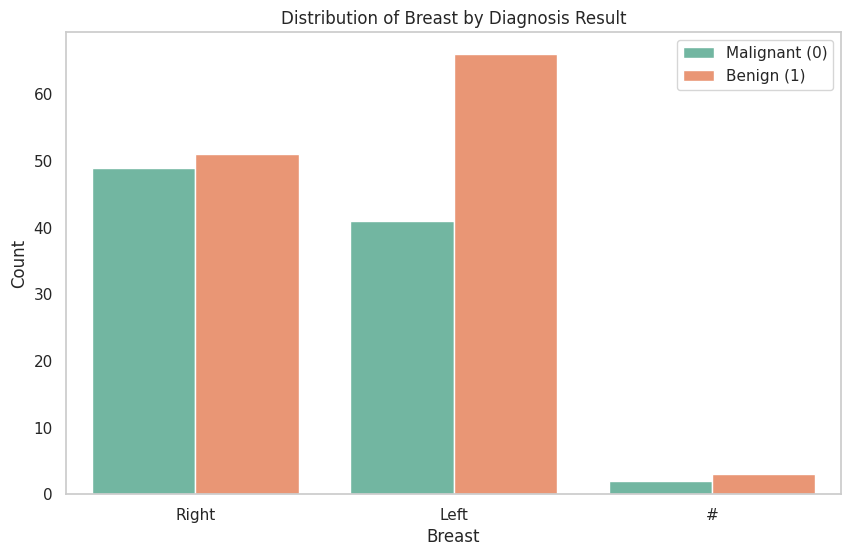

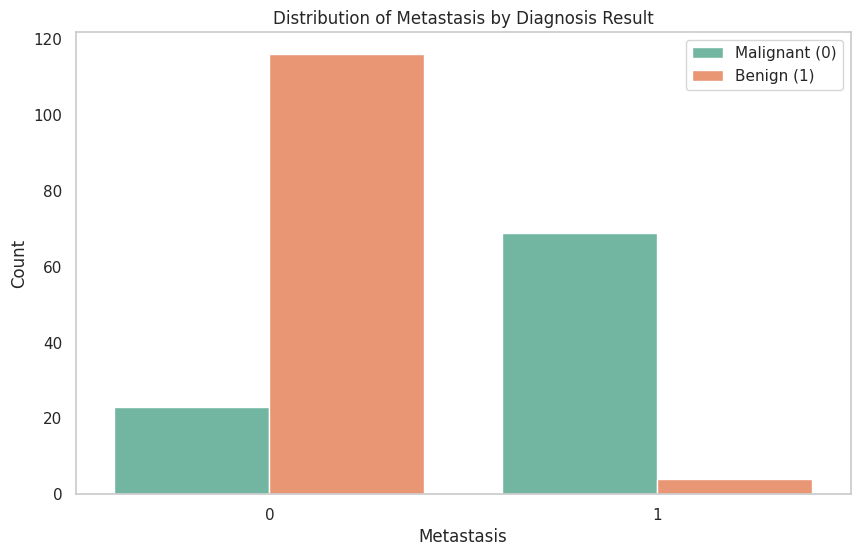

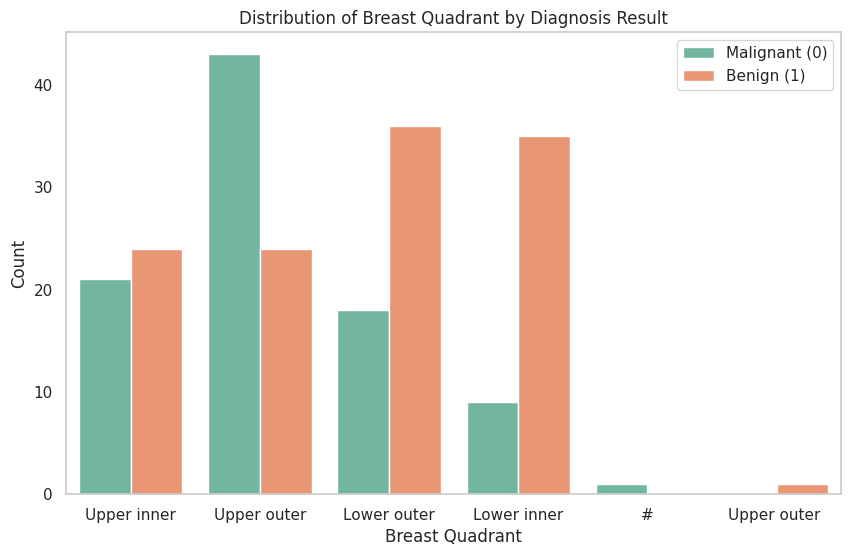

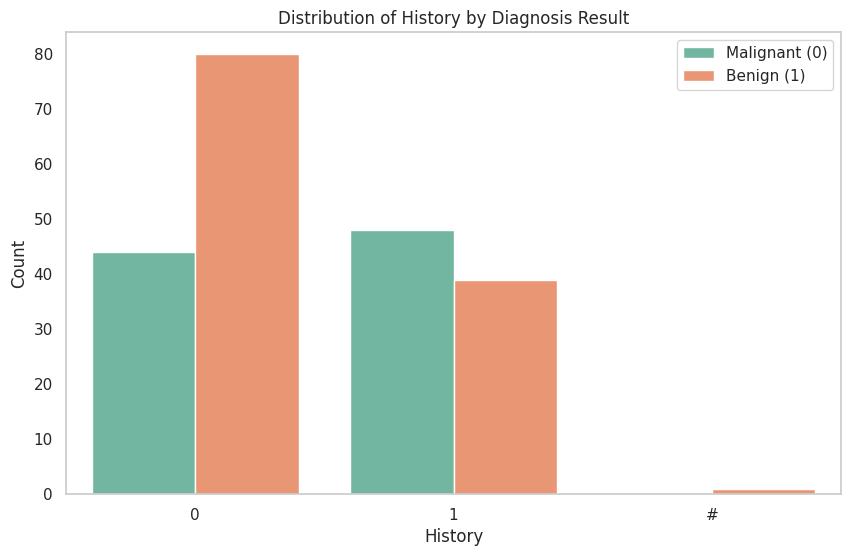

In [22]:
# Ensure pandas is imported
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assume train_df is already loaded. The Diagnosis Result column should be mapped to 0 and 1
# as per the user's previous code cells.

# --- Cleaning Step for 'Tumor Size (cm)' ---
# This step is critical to prevent the ValueError during plotting.
# We repeat it here to be sure the DataFrame used for plotting is clean.

# First, ensure the column is treated as string to safely apply string methods
if 'Tumor Size (cm)' in train_df.columns:
    train_df['Tumor Size (cm)'] = train_df['Tumor Size (cm)'].astype(str)

    # Remove any '#' characters
    train_df['Tumor Size (cm)'] = train_df['Tumor Size (cm)'].str.replace('#', '', regex=False)

    # Convert the cleaned column to numeric, coercing errors to NaN
    train_df['Tumor Size (cm)'] = pd.to_numeric(train_df['Tumor Size (cm)'], errors='coerce')

    # Handle NaN values created by errors='coerce'. Dropping rows with NaN in this specific column.
    initial_shape = train_df.shape
    train_df.dropna(subset=['Tumor Size (cm)'], inplace=True)
    if train_df.shape != initial_shape:
        print(f"\nDropped {initial_shape[0] - train_df.shape[0]} rows with NaN in 'Tumor Size (cm)'. New shape: {train_df.shape}")

    # Verification
    print(f"Data type of 'Tumor Size (cm)' after cleaning: {train_df['Tumor Size (cm)'].dtype}")
    if train_df['Tumor Size (cm)'].isnull().sum() > 0:
        print(f"Warning: {train_df['Tumor Size (cm)'].isnull().sum()} NaN values remain in 'Tumor Size (cm)'.")

# --- Define Features for Plotting ---
# Select all columns except 'Year' and 'Diagnosis Result' to be plotted as features.
# We assume 'Year' is not a feature for diagnosis.
# 'Diagnosis Result' is the target/hue variable.
features_to_plot = train_df.drop(columns=['Year', 'Diagnosis Result'], errors='ignore').columns

print(f"\nFeatures selected for distribution plotting: {list(features_to_plot)}")

# --- Plotting Step ---
# Create distribution plots for each selected feature, handling numeric and categorical differently.

for feature in features_to_plot:
    plt.figure(figsize=(10, 6))

    # Check if the feature column is numeric
    if pd.api.types.is_numeric_dtype(train_df[feature]):
        # Plot distribution for numeric features using histplot
        sns.histplot(data=train_df, x=feature, hue='Diagnosis Result', kde=True, element='step', palette='Set2')
        plt.title(f'Distribution of {feature} by Diagnosis Result')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        # Manually create legend based on the mapped values and original labels.
        # Assuming 0 maps to 'Malignant' and 1 maps to 'Benign'.
        handles, _ = plt.gca().get_legend_handles_labels()
        plt.legend(handles, ['Malignant (0)', 'Benign (1)']) # Assuming 0=Malignant, 1=Benign

    # Check if the feature column is of object type (likely categorical)
    elif pd.api.types.is_object_dtype(train_df[feature]):
        # Plot count for categorical features using countplot
        # Ensure 'Diagnosis Result' is treated as a categorical variable for hue in countplot
        sns.countplot(data=train_df, x=feature, hue='Diagnosis Result', palette='Set2')
        plt.title(f'Distribution of {feature} by Diagnosis Result')
        plt.xlabel(feature)
        plt.ylabel('Count')
        # Manually create legend based on the mapped values and original labels.
        # Assuming 0 maps to 'Malignant' and 1 maps to 'Benign'.
        # Note: countplot hue legend might automatically use the hue values (0, 1).
        # If you want original labels, you might need to adjust the hue data or legend labels explicitly.
        # For simplicity, we'll assume the default hue legend is acceptable or adjust manually if needed.
        handles, _ = plt.gca().get_legend_handles_labels()
        plt.legend(handles, ['Malignant (0)', 'Benign (1)']) # Assuming 0=Malignant, 1=Benign

    else:
        # Print a message for other data types that are not plotted
        print(f"Skipping plot for column '{feature}' with data type: {train_df[feature].dtype}")
        plt.close() # Close the empty figure
        continue # Skip to the next feature

    plt.grid(False) # Remove grid lines as per original plot style
    plt.show()

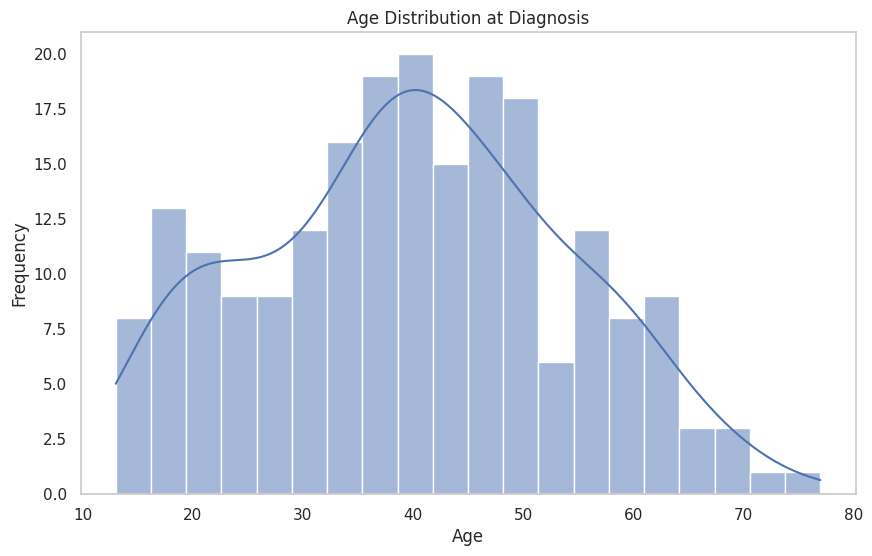

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df['Age'], bins=20, kde=True)
plt.title('Age Distribution at Diagnosis')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

data cleaning

In [24]:
print("Number of missing values ​​per column:")
print(train_df.isnull().sum())

Number of missing values ​​per column:
Year                0
Age                 0
Menopause           0
Tumor Size (cm)     0
Inv-Nodes           0
Breast              0
Metastasis          0
Breast Quadrant     0
History             0
Diagnosis Result    0
dtype: int64


feature engineering

In [25]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
label_encoder = LabelEncoder()

# Applying to columns transforming into numbers
df['Breast'] = label_encoder.fit_transform(df['Breast'])
df['Breast Quadrant'] = label_encoder.fit_transform(df['Breast Quadrant'])
df['Diagnosis Result'] = label_encoder.fit_transform(df['Diagnosis Result'])

# Viewing
label_encoder

LabelEncoder()

In [26]:
df.replace('#', pd.NA, inplace=True)

In [27]:
df.head()

,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,2019.0,40,1,2.0,0.0,0,0.0,0,0.0,1
1,2019.0,39,1,2.0,0.0,0,0.0,0,0.0,1
2,2019.0,45,0,4.0,0.0,0,0.0,0,0.0,1
3,2019.0,26,1,3.0,0.0,0,0.0,0,1.0,1
4,2019.0,21,1,1.0,0.0,0,0.0,0,1.0,1


In [28]:
categorical_cols = df.select_dtypes(include=['object']).columns

# Viewing dataset
df.head()

,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,2019.0,40,1,2.0,0.0,0,0.0,0,0.0,1
1,2019.0,39,1,2.0,0.0,0,0.0,0,0.0,1
2,2019.0,45,0,4.0,0.0,0,0.0,0,0.0,1
3,2019.0,26,1,3.0,0.0,0,0.0,0,1.0,1
4,2019.0,21,1,1.0,0.0,0,0.0,0,1.0,1


In [29]:
df = df.dropna()

target column division

In [30]:
X = df.drop(columns=['Diagnosis Result'])

# Target variable
y = df['Diagnosis Result']

In [31]:
#visual of x data
X.shape

(211, 9)

In [32]:
#visual of y data
y.shape

(211,)

model training

In [34]:
from sklearn.model_selection import train_test_split

# Training and testing division
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Viewing training data
print("Viewing rows and columns given by X train", X_train.shape)

# Viewing test data
print("Viewing rows and columns given y train", y_train.shape)

Viewing rows and columns given by X train (168, 9)
Viewing rows and columns given y train (168,)


machine learning

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Define the templates and parameters for GridSearchCV
models = [
          ('Random Forest', RandomForestClassifier(random_state=42), {'n_estimators': [50, 100, 200]}),
          ('Logistic Regression', LogisticRegression(random_state=50), {'C': [0.01, 0.1, 1, 10]}),
          ('Gradient Boosting', GradientBoostingClassifier(random_state=42), {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]})
         ]

# Configure GridSearchCV
results = []
kf = KFold(n_splits=25, shuffle=True, random_state=42)

for name, model, params in models:
    pipeline = Pipeline([('scaler', StandardScaler()),('classifier', model)])
    grid_search = GridSearchCV(pipeline, param_grid={'classifier__' + key: value for key, value in params.items()}, cv=kf, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    results.append((name, accuracy, roc_auc, y_pred, y_pred_proba, best_model))

# Display all tested hyperparameter combinations and their respective accuracies
results = pd.DataFrame(grid_search.cv_results_)
print(results[['params', 'mean_test_score', 'rank_test_score']])

                                              params  mean_test_score  \
0  {'classifier__learning_rate': 0.01, 'classifie...              NaN   
1  {'classifier__learning_rate': 0.01, 'classifie...              NaN   
2  {'classifier__learning_rate': 0.01, 'classifie...              NaN   
3  {'classifier__learning_rate': 0.1, 'classifier...              NaN   
4  {'classifier__learning_rate': 0.1, 'classifier...              NaN   
5  {'classifier__learning_rate': 0.1, 'classifier...              NaN   
6  {'classifier__learning_rate': 1, 'classifier__...              NaN   
7  {'classifier__learning_rate': 1, 'classifier__...              NaN   
8  {'classifier__learning_rate': 1, 'classifier__...              NaN   

   rank_test_score  
0                1  
1                1  
2                1  
3                1  
4                1  
5                1  
6                1  
7                1  
8                1  


In [36]:
train_accuracy = accuracy_score(y_train, best_model.predict(X_train))
test_accuracy = accuracy_score(y_test, best_model.predict(X_test))
print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

Training Accuracy: 0.9166666666666666
Testing Accuracy: 0.9069767441860465


In [37]:
#model prediction
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

features importance

LogisticRegression does not support feature importances.


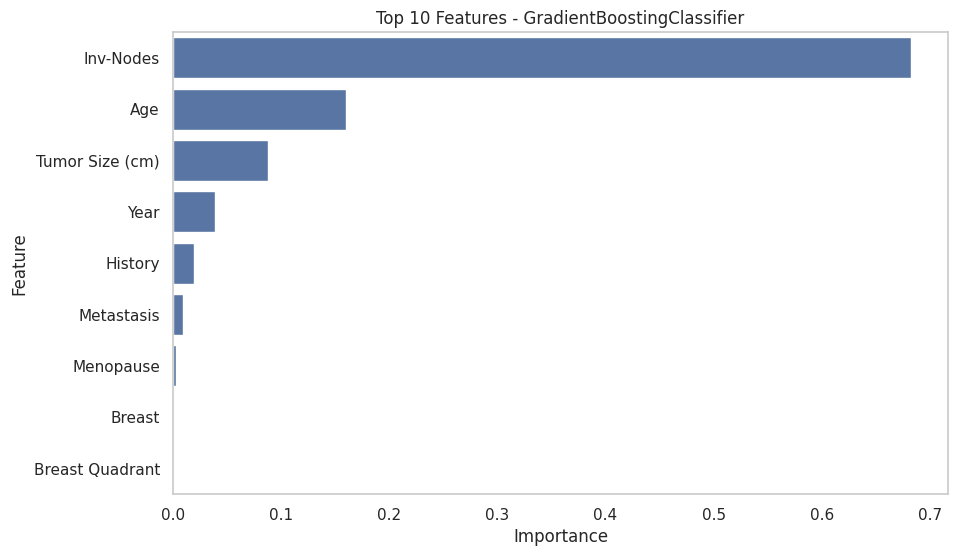

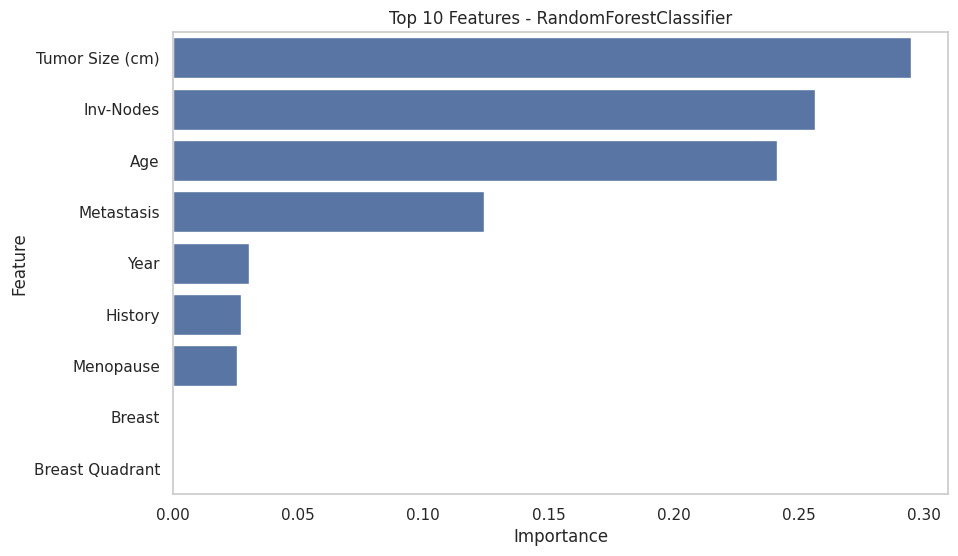

In [38]:
models_with_feature_importances = [("LogisticRegression", LogisticRegression(random_state=50)),
                                   ("GradientBoostingClassifier", GradientBoostingClassifier(random_state=42)),
                                   ("RandomForestClassifier", RandomForestClassifier(n_estimators=100,
                                                                                     random_state=42))]

# Iterate over models
for model_name, model in models_with_feature_importances:

    # Train model
    model.fit(X_train, y_train)

    # Get importance of features
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
    else:
        # If the model does not have feature_importances_, continue to the next model
        print(f"{model_name} does not support feature importances.")
        continue

    # Create DataFrame for easier viewing
    feature_importances_df = pd.DataFrame({'Feature': X_train.columns,
                                           'Importance': feature_importances})

    # Sort by importance
    feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances_df[:10])
    plt.title(f"Top 10 Features - {model_name}")
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(False)
    plt.show()

model evaluation

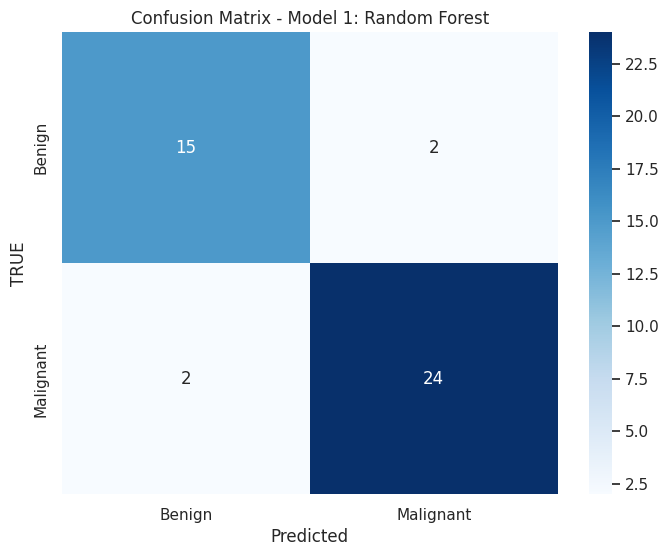

Model 1: Random Forest
Confusion Matrix
 [[15  2]
 [ 2 24]]
True Positives (TP) = 15
True Negatives (TN) = 24
False Positives (FP) = 2
False Negatives (FN) = 2
------------------


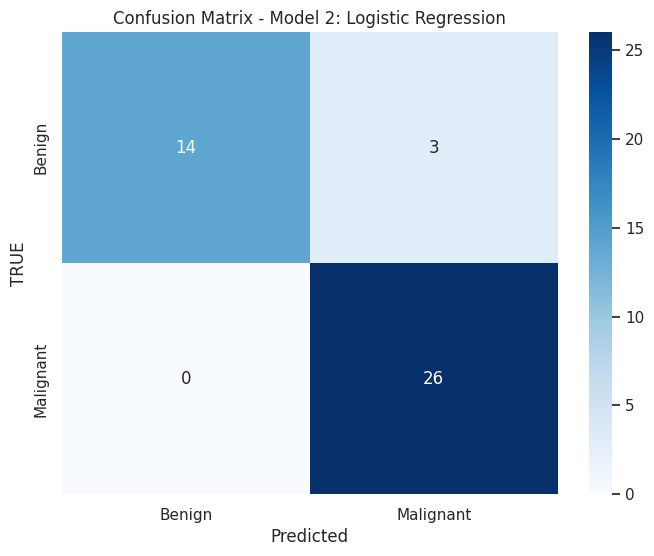

Model 2: Logistic Regression
Confusion Matrix
 [[14  3]
 [ 0 26]]
True Positives (TP) = 14
True Negatives (TN) = 26
False Positives (FP) = 3
False Negatives (FN) = 0
------------------


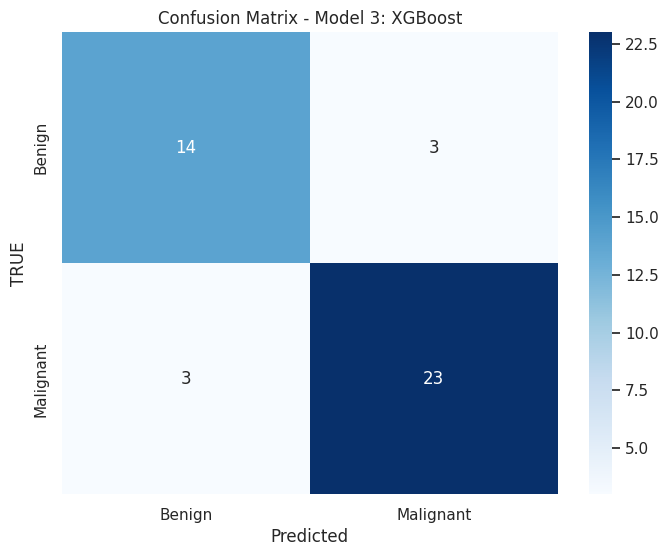

Model 3: XGBoost
Confusion Matrix
 [[14  3]
 [ 3 23]]
True Positives (TP) = 14
True Negatives (TN) = 23
False Positives (FP) = 3
False Negatives (FN) = 3
------------------


In [39]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Import the necessary classifier classes
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
# Import XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Define the templates and parameters for GridSearchCV
models = [
    ('Random Forest', RandomForestClassifier(random_state=42), {'n_estimators': [50, 100, 200]}),
    ('Logistic Regression', LogisticRegression(random_state=50), {'C': [0.01, 0.1, 1, 10]}),
    ('XGBoost', XGBClassifier(random_state=42), {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7]})
]

# Configure GridSearchCV
results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)
metricas = []

for name, model, params in models:
    pipeline = Pipeline([('scaler', StandardScaler()),('classifier', model)])
    grid_search = GridSearchCV(pipeline, param_grid={'classifier__' + key: value for key, value in params.items()}, cv=kf, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    report = classification_report(y_test, y_pred, output_dict=True)

    metrics = {"Model": name,
               "Accuracy": accuracy,
               "Precision": report['weighted avg']['precision'],
               "Recall": report['weighted avg']['recall'],
               "F1-score": report['weighted avg']['f1-score'],
               "Support": report['weighted avg']['support']}
    metricas.append(metrics)
    results.append((name, accuracy, roc_auc, y_pred, y_pred_proba, best_model))

# Display the confusion matrices
for i, (name, accuracy, roc_auc, y_pred, y_pred_proba, best_model) in enumerate(results):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted')
    plt.ylabel('TRUE')
    plt.title(f'Confusion Matrix - Model {i+1}: {name}')
    plt.show()
    print(f'Model {i+1}: {name}')
    print('Confusion Matrix\n', cm)
    print('True Positives (TP) =', cm[0, 0])
    print('True Negatives (TN) =', cm[1, 1])
    print('False Positives (FP) =', cm[0, 1])
    print('False Negatives (FN) =', cm[1, 0])
    print("------------------")

In [40]:
#classification
for i, (name, accuracy, roc_auc, y_pred, y_pred_proba, best_model) in enumerate(results):
    print(f'Model {i+1}: {name} - Accuracy: {accuracy:.4f}, ROC AUC: {roc_auc:.4f}')
    report = classification_report(y_test, y_pred, target_names=['Benign', 'Malignant'])
    print(f'Classification Report - Model {i+1}: {name}\n')
    print(report)
    print("------------------")

Model 1: Random Forest - Accuracy: 0.9070, ROC AUC: 0.9729
Classification Report - Model 1: Random Forest

              precision    recall  f1-score   support

      Benign       0.88      0.88      0.88        17
   Malignant       0.92      0.92      0.92        26

    accuracy                           0.91        43
   macro avg       0.90      0.90      0.90        43
weighted avg       0.91      0.91      0.91        43

------------------
Model 2: Logistic Regression - Accuracy: 0.9302, ROC AUC: 0.9819
Classification Report - Model 2: Logistic Regression

              precision    recall  f1-score   support

      Benign       1.00      0.82      0.90        17
   Malignant       0.90      1.00      0.95        26

    accuracy                           0.93        43
   macro avg       0.95      0.91      0.92        43
weighted avg       0.94      0.93      0.93        43

------------------
Model 3: XGBoost - Accuracy: 0.8605, ROC AUC: 0.9706
Classification Report - Model

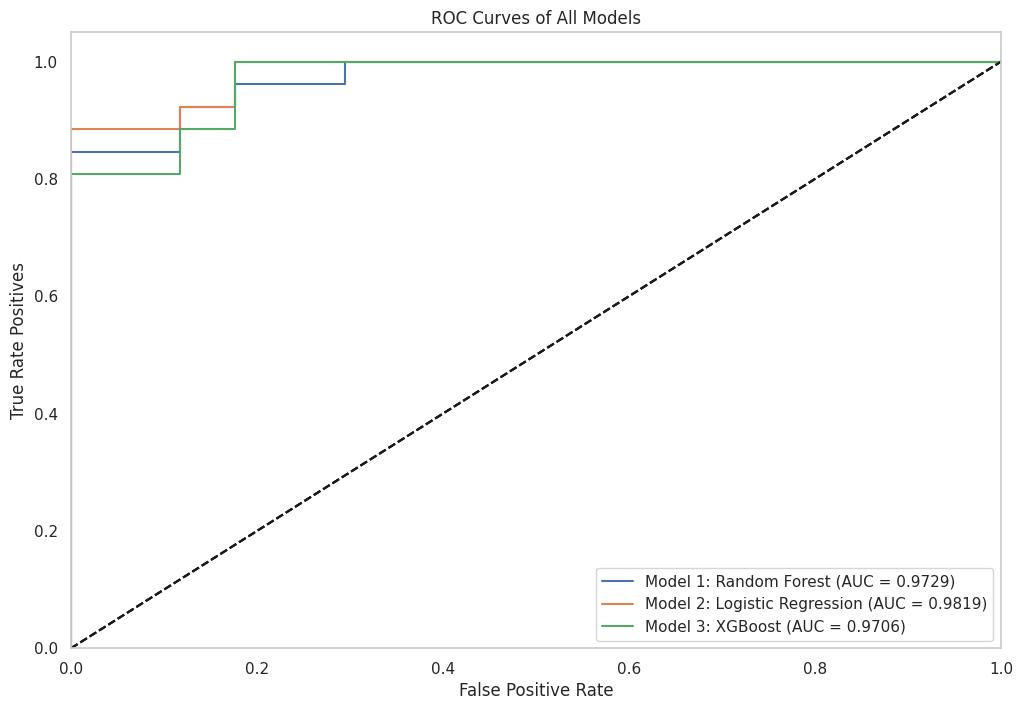

In [41]:
#ROC

plt.figure(figsize=(12, 8))
for i, (name, accuracy, roc_auc, y_pred, y_pred_proba, best_model) in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba )
    plt.plot(fpr, tpr, label=f'Model {i+1}: {name} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1] , 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Rate Positives')
    plt.title('ROC Curves of All Models')
    plt.legend(loc='lower right')
    plt.grid(False)
plt.show()

In [42]:
#model results

df_metricas = pd.DataFrame(metricas)

# Function to highlight the maximum value in each column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

# Apply the highlight function
df_metricas_styled = df_metricas.style.apply(highlight_max, subset=['Accuracy', 'Precision', 'Recall', 'F1-score'])

# Display the DataFrame with the metrics
df_metricas_styled

,Model,Accuracy,Precision,Recall,F1-score,Support
0,Random Forest,0.906977,0.906977,0.906977,0.906977,43.000000
1,Logistic Regression,0.930233,0.937450,0.930233,0.928759,43.000000
2,XGBoost,0.860465,0.860465,0.860465,0.860465,43.000000


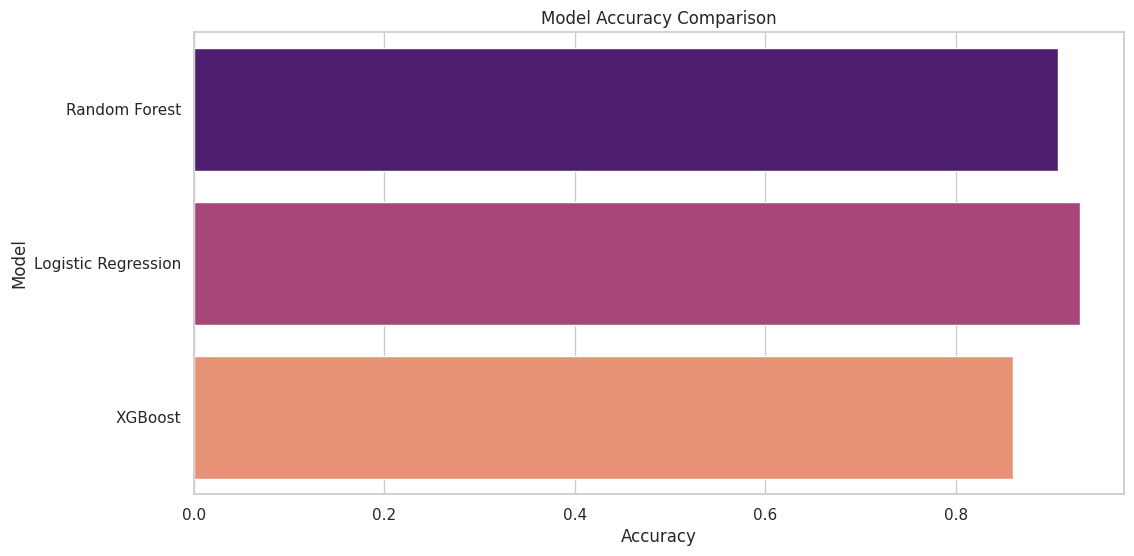

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_metricas was created in a previous cell and contains model performance metrics

# Extract model names and accuracy scores from the df_metricas DataFrame
model_name = df_metricas['Model'].tolist()
model_acc = df_metricas['Accuracy'].tolist()

plt.figure(figsize=(12,6))
# Use the extracted model names and accuracies for the bar plot
sns.barplot(x=model_acc, y=model_name, palette='magma')
plt.title('Model Accuracy Comparison') # Added a title for clarity
plt.xlabel('Accuracy') # Added x-axis label
plt.ylabel('Model') # Added y-axis label
plt.show() # Display the plot